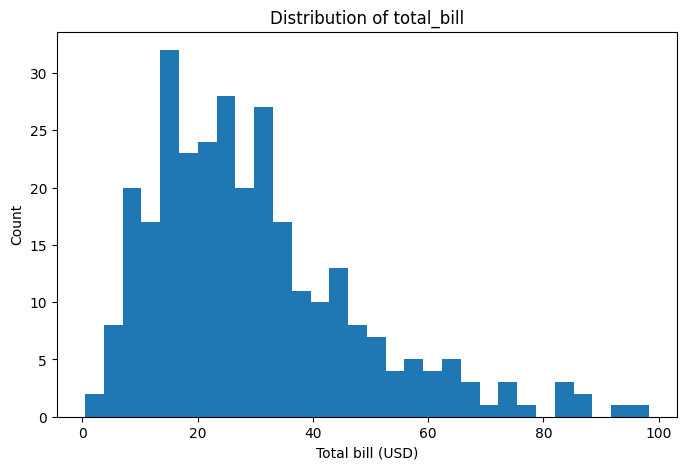

/tmp/ipython-input-2473376609.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=days, showmeans=True)


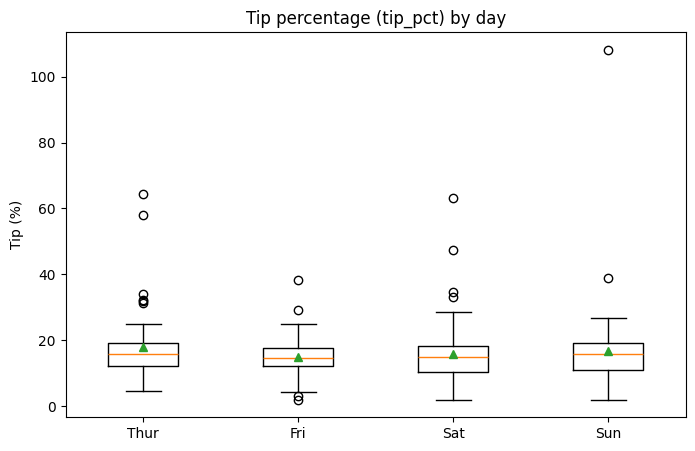

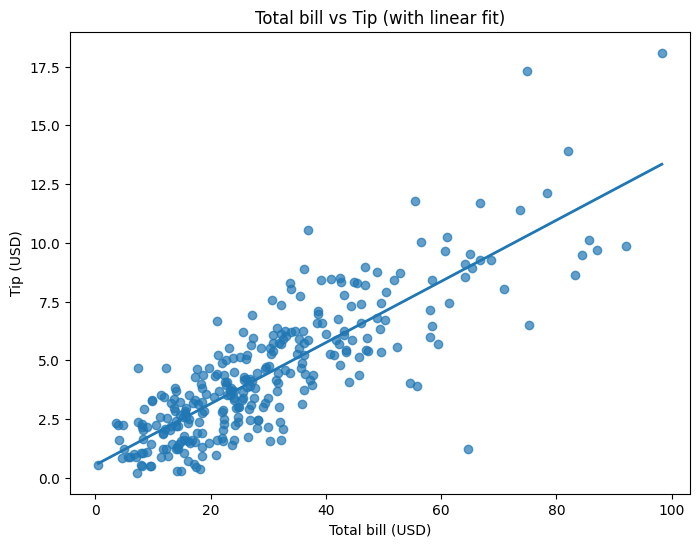

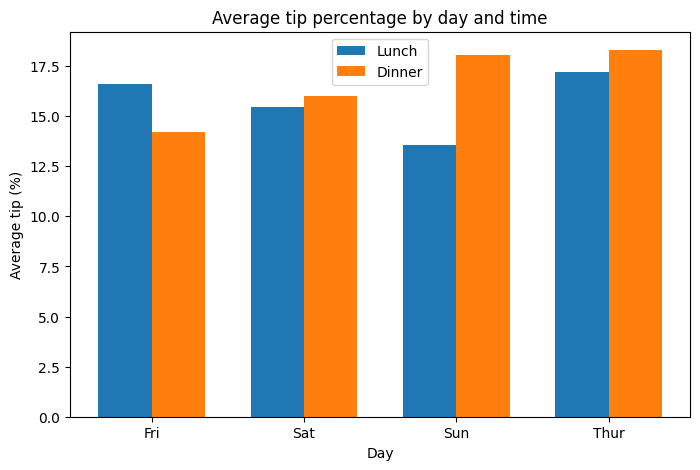

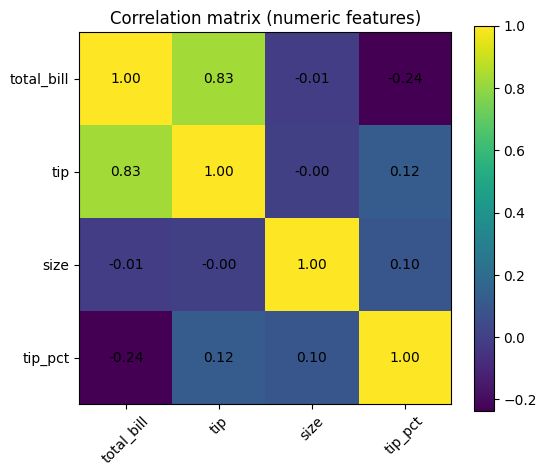

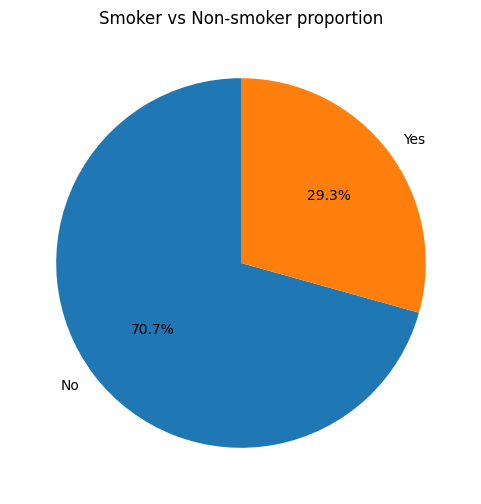

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)
n = 300

# ===== If you have an online dataset, replace the next block with:
# df = pd.read_csv("https://your-url/yourfile.csv")
# and then compute df['tip_pct'] = df['tip'] / df['total_bill'] * 100
# ========================================== #

# Synthetic "tips"-like dataset (used because network was unavailable in the runtime)
total_bill = np.round(np.random.gamma(shape=2.5, scale=12, size=n), 2)
base_tip_pct = np.random.normal(loc=15, scale=3, size=n)
tip = np.round(total_bill * (base_tip_pct/100) + np.random.normal(0, 1.2, size=n), 2)
sex = np.random.choice(['Male','Female'], size=n)
smoker = np.random.choice(['Yes','No'], size=n, p=[0.3,0.7])
day = np.random.choice(['Thur','Fri','Sat','Sun'], size=n, p=[0.2,0.25,0.3,0.25])
time = np.random.choice(['Lunch','Dinner'], size=n, p=[0.35,0.65])
size = np.random.choice([1,2,3,4,5,6], size=n, p=[0.05,0.5,0.15,0.2,0.07,0.03])
tip = np.where(tip <= 0, np.abs(tip) + 0.5, tip)

df = pd.DataFrame({
    'total_bill': total_bill,
    'tip': np.round(tip,2),
    'sex': sex,
    'smoker': smoker,
    'day': day,
    'time': time,
    'size': size
})
df['tip_pct'] = df['tip'] / df['total_bill'] * 100

out_dir = "./tips_viz_outputs"
os.makedirs(out_dir, exist_ok=True)

# Histogram of total_bill
plt.figure(figsize=(8,5))
plt.hist(df['total_bill'], bins=30)
plt.title("Distribution of total_bill")
plt.xlabel("Total bill (USD)")
plt.ylabel("Count")
plt.savefig(out_dir + "/hist_total_bill.png")
plt.show()

# Boxplot tip_pct by day
plt.figure(figsize=(8,5))
days = ['Thur','Fri','Sat','Sun']
data_to_plot = [df[df['day']==d]['tip_pct'] for d in days]
plt.boxplot(data_to_plot, labels=days, showmeans=True)
plt.title("Tip percentage (tip_pct) by day")
plt.ylabel("Tip (%)")
plt.savefig(out_dir + "/box_tip_pct_by_day.png")
plt.show()

# Scatter with regression (total_bill vs tip)
x = df['total_bill'].values
y = df['tip'].values
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.7)
plt.plot(np.sort(x), poly1d_fn(np.sort(x)), linewidth=2)
plt.title("Total bill vs Tip (with linear fit)")
plt.xlabel("Total bill (USD)")
plt.ylabel("Tip (USD)")
plt.savefig(out_dir + "/scatter_total_vs_tip_reg.png")
plt.show()

# Bar chart average tip_pct by day & time
grouped = df.groupby(['day','time'])['tip_pct'].mean().unstack().fillna(0)
plt.figure(figsize=(8,5))
ind = np.arange(len(grouped.index))
width = 0.35
plt.bar(ind - width/2, grouped.get('Lunch', pd.Series([0]*len(ind))).values, width, label='Lunch')
plt.bar(ind + width/2, grouped.get('Dinner', pd.Series([0]*len(ind))).values, width, label='Dinner')
plt.xticks(ind, grouped.index)
plt.xlabel("Day")
plt.ylabel("Average tip (%)")
plt.title("Average tip percentage by day and time")
plt.legend()
plt.savefig(out_dir + "/bar_avg_tip_pct_by_day_time.png")
plt.show()

# Correlation heatmap
num_cols = ['total_bill','tip','size','tip_pct']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')
plt.title("Correlation matrix (numeric features)")
plt.savefig(out_dir + "/corr_heatmap.png")
plt.show()

# Pie chart smoker proportion
smoker_counts = df['smoker'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(smoker_counts.values, labels=smoker_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Smoker vs Non-smoker proportion")
plt.savefig(out_dir + "/pie_smoker_proportion.png")
plt.show()

# CSV summary by day for portfolio
summary_by_day = df.groupby('day').agg(
    count=('tip','size'),
    avg_total_bill=('total_bill','mean'),
    avg_tip=('tip','mean'),
    avg_tip_pct=('tip_pct','mean')
).reset_index()
summary_by_day.to_csv(out_dir + "/summary_by_day.csv", index=False)
